<a href="https://colab.research.google.com/github/hasanmisaii/Automated-ML-using-Google-Colab/blob/main/XAI_Fault_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
steel_plates_faults = fetch_ucirepo(id=198)

# data (as pandas dataframes)
X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

# metadata
print(steel_plates_faults.metadata)

{'uci_id': 198, 'name': 'Steel Plates Faults', 'repository_url': 'https://archive.ics.uci.edu/dataset/198/steel+plates+faults', 'data_url': 'https://archive.ics.uci.edu/static/public/198/data.csv', 'abstract': 'A dataset of steel platesâ€™ faults, classified into 7 different types. \nThe goal was to train machine learning for automatic pattern recognition.\n', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1941, 'num_features': 27, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2010, 'last_updated': 'Tue Apr 09 2024', 'dataset_doi': '10.24432/C5J88N', 'creators': ['M Buscema', 'S Terzi', 'W Tastle'], 'intro_paper': None, 'additional_info': {'summary': 'Type of dependent variables (7 Types of Steel Plates 

In [ ]:
# variable information
steel_plates_faults.variables

,name,role,type,demographic,description,units,missing_values
0,X_Minimum,Feature,Integer,None,None,None,no
1,X_Maximum,Feature,Integer,None,None,None,no
2,Y_Minimum,Feature,Integer,None,None,None,no
3,Y_Maximum,Feature,Integer,None,None,None,no
4,Pixels_Areas,Feature,Integer,None,None,None,no
5,X_Perimeter,Feature,Integer,None,None,None,no
6,Y_Perimeter,Feature,Integer,None,None,None,no
7,Sum_of_Luminosity,Feature,Integer,None,None,None,no
8,Maximum_of_Luminosity,Feature,Integer,None,None,None,no
9,Length_of_Conveyer,Feature,Integer,None,None,None,no


In [ ]:
# prompt: make a dataframe of the data
import pandas as pd
# Combine features and target into a single DataFrame
df = pd.concat([X, y], axis=1)

# Display the first few rows of the DataFrame
print(df.head())

   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306     498078     498335          2409           60   

   Y_Perimeter  Sum_of_Luminosity  Maximum_of_Luminosity  Length_of_Conveyer  \
0           44              24220                    108                1687   
1           30              11397                    123                1687   
2           19               7972                    125                1623   
3           45              18996                    126                1353   
4          260             246930                    126                1353   

   ...  Luminosity_Index  SigmoidOfAreas  Minimum_of_Luminosit

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [ ]:
# !pip install matplotlib

# prompt: make a pie and histogram plot of the seven last column

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame as defined in the previous code

# Use the explicitly defined 'fault_labels' to select the correct columns
# The 'Fault_Type' column, which contains strings, was mistakenly included in 'last_seven_cols'
# when using iloc[:, -7:] after it was added to the DataFrame.
# This caused the TypeError during summation for the pie chart.
fault_labels = ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
last_seven_cols = df[fault_labels]

# Calculate the sum of each column for the pie chart
col_sums = last_seven_cols.sum()


# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(col_sums, labels=col_sums.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Different Faults')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

KeyError: "None of [Index(['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps',\n       'Other_Faults'],\n      dtype='object')] are in the [columns]"

In [ ]:
# Select the last seven columns
last_seven_cols = df.iloc[:, -7:]

# Function to determine the fault type
def get_fault_type(row):
    for col in last_seven_cols.columns:
        if row[col] == 1:
            return col
    return "Unknown"  # Handle cases where none of the fault columns are 1

# Apply the function to create the 'Fault_Type' column
df['Fault_Type'] = df.apply(get_fault_type, axis=1)

# Display the first few rows of the DataFrame with the new column
print(df.head())

   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306     498078     498335          2409           60   

   Y_Perimeter  Sum_of_Luminosity  Maximum_of_Luminosity  Length_of_Conveyer  \
0           44              24220                    108                1687   
1           30              11397                    123                1687   
2           19               7972                    125                1623   
3           45              18996                    126                1353   
4          260             246930                    126                1353   

   ...  SigmoidOfAreas  Minimum_of_Luminosity  Pastry  Z_Scrat

In [ ]:
df['Fault_Type'].value_counts()

,count
Fault_Type,
Other_Faults,673
Bumps,402
K_Scratch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55


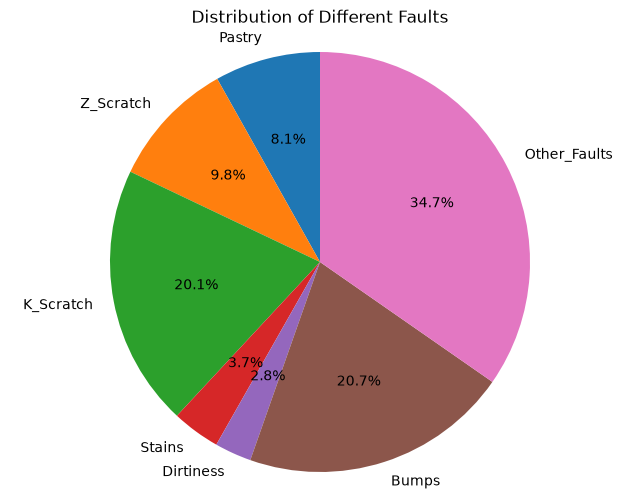

In [ ]:
# Calculate the sum of each column for the pie chart
col_sums = last_seven_cols.sum()

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(col_sums, labels=col_sums.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Different Faults')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# Save the DataFrame to an Excel file
steel_plates_faults = df
df.to_excel('steel_plates_faults.xlsx', index=False)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# 1. Load dataset
df = pd.read_excel("/content/steel_plates_faults.xlsx")

In [ ]:
# 2. One-hot labels to multiclass
fault_labels = ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
df['Fault_Type'] = df[fault_labels].idxmax(axis=1)

In [ ]:
MultiClass_data = df.drop(columns=fault_labels)

In [ ]:
# Save the MultiClass_data DataFrame to a CSV file
MultiClass_data.to_csv('multiclass_data.csv', index=False)

In [ ]:
# Test and Train
X = df.drop(columns=fault_labels + ['Fault_Type'])
y = df['Fault_Type']

In [ ]:
# 3. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 4. Train-test split (before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
y_train.value_counts()

,count
Fault_Type,
Other_Faults,538
Bumps,321
K_Scratch,313
Z_Scratch,152
Pastry,126
Stains,58
Dirtiness,44


In [ ]:
# 5. Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_smote.value_counts()

,count
Fault_Type,
K_Scratch,538
Bumps,538
Other_Faults,538
Z_Scratch,538
Pastry,538
Dirtiness,538
Stains,538


In [ ]:
# 6. Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

In [ ]:
# 7. Train and evaluate each model
labels = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
conf_matrices = {}
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    conf_matrices[name] = cm

In [ ]:
conf_matrices

{'Random Forest': array([[ 21,   0,   0,   0,   0,   2,   9],
        [  0,  34,   0,   0,   0,   2,   2],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,  12,   0,   1,   1],
        [  0,   0,   0,   0,  10,   0,   1],
        [  4,   0,   0,   0,   1,  57,  19],
        [ 15,   1,   0,   1,   0,  16, 101]]),
 'AdaBoost': array([[19,  1,  0,  0,  3,  2,  6],
        [ 4, 23,  0,  0,  0,  2,  9],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 12,  1,  1,  0],
        [ 3,  1,  0,  0,  6,  0,  1],
        [ 4,  0,  0,  0,  3, 21, 49],
        [20,  8,  0,  1, 10, 15, 78]]),
 'Decision Tree': array([[12,  2,  0,  0,  1, 11,  6],
        [ 2, 33,  0,  0,  0,  2,  1],
        [ 0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 10,  0,  3,  1],
        [ 0,  0,  0,  0,  8,  0,  3],
        [ 6,  1,  0,  0,  1, 52, 21],
        [11,  5,  0,  1,  3, 29, 83]]),
 'SVM': array([[23,  1,  0,  0,  3,  4,  1],
        [ 0, 34,  0,  0,  0,  1,  3],
        [ 0,  0,  

In [ ]:
# 8. Define misclassification cost matrix
label_index = {label: idx for idx, label in enumerate(labels)}
cost_matrix = np.full((7, 7), 10)  # default cost
np.fill_diagonal(cost_matrix, 0)
cost_matrix[label_index['Bumps'], label_index['Other_Faults']] = 80
cost_matrix[label_index['Other_Faults'], label_index['Bumps']] = 80
cost_matrix[label_index['Other_Faults'], label_index['Pastry']] = 50
cost_matrix[label_index['Bumps'], label_index['Pastry']] = 30
cost_matrix[label_index['Other_Faults'], label_index['Z_Scratch']] = 60

In [ ]:
# Hypothetical cost matrix (cost[i][j] = cost of class i being predicted as class j)
cost_matrix = np.array([
    [0, 20, 25, 80, 30, 40, 60],  # Bumps
    [20, 0, 20, 60, 95, 85, 90],  # Dirtiness
    [25, 20, 0, 70, 30, 70, 80],  # K_Scratch
    [80, 60, 70, 0, 50, 60, 60],  # Other_Faults
    [30, 95, 30, 50, 0, 30, 40],  # Pastry
    [40, 85, 70, 60, 30, 0, 50],  # Stains
    [60, 90, 80, 60, 40, 50, 0]   # Z_Scratch
])



In [ ]:
# Define the custom misclassification cost matrix
cost_matrix = np.full((7, 7), 10)  # default cost is 10
np.fill_diagonal(cost_matrix, 0)  # no cost for correct classifications

In [ ]:
print(cost_matrix)

[[ 0 10 10 10 10 10 10]
 [10  0 10 10 10 10 10]
 [10 10  0 10 10 10 10]
 [10 10 10  0 10 10 10]
 [10 10 10 10  0 10 10]
 [10 10 10 10 10  0 10]
 [10 10 10 10 10 10  0]]


In [ ]:
# 9. Calculate total cost per model
model_costs = {}
for name, cm in conf_matrices.items():
    total_cost = sum(
        cm[i][j] * cost_matrix[i][j]
        for i in range(7) for j in range(7) if i != j
    )
    model_costs[name] = total_cost

In [ ]:
# 10. Print summary
print("=== Misclassification Costs After SMOTE ===")
for model, cost in model_costs.items():
    print(f"{model}: {cost} units")


=== Misclassification Costs After SMOTE ===
Random Forest: 750 units
AdaBoost: 2580 units
Decision Tree: 1100 units
SVM: 1030 units
Naive Bayes: 1290 units


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Misclassification cost data
model_costs = {
    "Auto-ML": 0,
    "Random Forest": 780,
    "AdaBoost": 1820,
    "Decision Tree": 990,
    "SVM": 970,
    "Naive Bayes": 1520
}

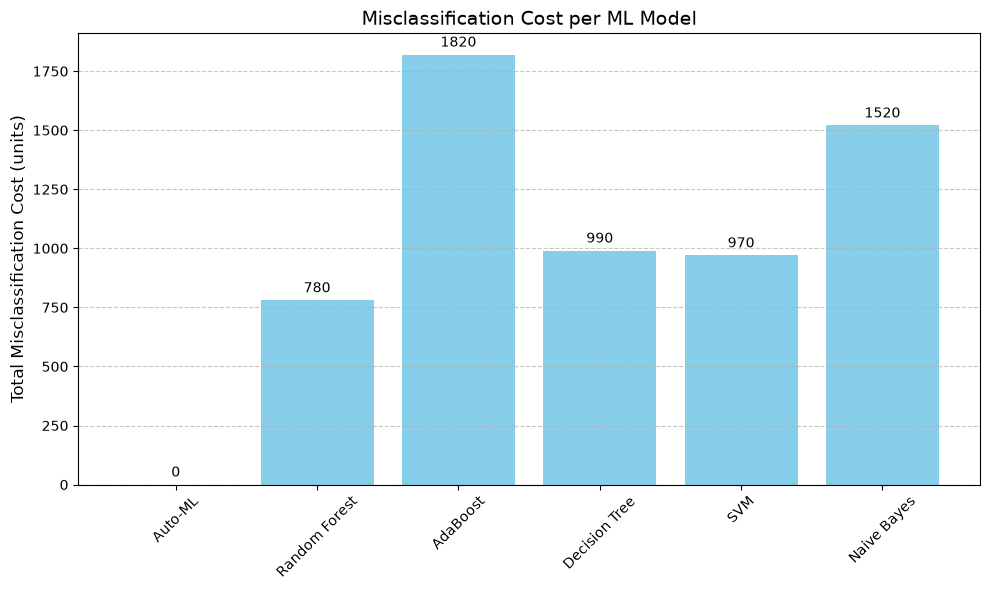

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(model_costs.keys(), model_costs.values(), color='skyblue')
plt.title("Misclassification Cost per ML Model", fontsize=14)
plt.ylabel("Total Misclassification Cost (units)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 20, f'{yval}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

In [ ]:
# Calculate metrics for each model
model_metrics = {}

for name, model in models.items():
    # Predict probabilities for AUC (for models that support it)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
        # Calculate AUC for multiclass (using 'ovo' or 'ovr' strategy)
        try:
          auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovo', labels=labels)
        except ValueError:
          auc = "N/A" # Handle cases where AUC cannot be calculated

    else:
        auc = "N/A"

    # Predict class labels for F1 and Accuracy
    y_pred = model.predict(X_test)

    # Calculate F1 score (using 'weighted' average for multiclass)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Calculate Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    model_metrics[name] = {
        "AUC": auc,
        "F1 Score": f1,
        "Accuracy": accuracy
    }

# Print the metrics
print("=== Model Performance Metrics ===")
for name, metrics in model_metrics.items():
    print(f"{name}:")
    print(f"  AUC: {metrics['AUC']:.4f}" if isinstance(metrics['AUC'], float) else f"  AUC: {metrics['AUC']}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")

=== Model Performance Metrics ===
Random Forest:
  AUC: N/A
  F1 Score: 0.7930
  Accuracy: 0.7892
AdaBoost:
  AUC: N/A
  F1 Score: 0.2198
  Accuracy: 0.2699
Decision Tree:
  AUC: N/A
  F1 Score: 0.6896
  Accuracy: 0.6864
SVM:
  AUC: N/A
  F1 Score: 0.7195
  Accuracy: 0.7172
Naive Bayes:
  AUC: N/A
  F1 Score: 0.5771
  Accuracy: 0.5990


### Using AutoGluon as an AutoML Alternative

Since PyCaret has compatibility issues with Python 3.12, we can explore other AutoML libraries like **AutoGluon**. AutoGluon is an open-source AutoML library developed by Amazon that can be used to quickly and easily train high-quality machine learning models for tabular, text, and image data. It automatically handles data preprocessing, model selection, and hyperparameter tuning.

In [ ]:
# Install a compatible scikit-learn version first, then AutoGluon
# !pip uninstall -y scikit-learn
# !pip install scikit-learn==1.1.3
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.7 MB/s eta 0:00:00
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.3
    Uninstalling pandas-3.0.3:
      Successfully uninstalled pandas-3.0.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.11.0
    Uninstalling matplotlib-3.11.0:
      Successfully unins

Now, let's prepare the data for AutoGluon. We need to define the features (`X_autogluon`) and the target variable (`y_autogluon`). AutoGluon handles data splitting internally, so we will use the full `df` (after dropping the original one-hot encoded fault labels) and specify the `Fault_Type` as the target column.

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

# AutoGluon works best with data in a single DataFrame
# We already have `df` with 'Fault_Type' as target and one-hot labels dropped.
# Let's ensure the target column is appropriate for classification.

# Identify features (all columns except 'Fault_Type' and original one-hot labels)
# The 'df' at this point should have 'Fault_Type' and no original one-hot labels if 'df = df.drop(columns=fault_labels)' was executed.

# If `df` still contains original one-hot labels, drop them again.
# Assuming `df` is the one from after `df = df.drop(columns=fault_labels)`
# The current `df` already has `Fault_Type` and no `fault_labels` from cell `lVDxi3SJmJlA`

df = df.drop(columns=fault_labels)
train_data = TabularDataset(df)
label = 'Fault_Type'

print(f"Training data shape: {train_data.shape}")
print(f"Target label: {label}")
print("First 5 rows of training data:")
print(train_data.head())


Training data shape: (1941, 28)
Target label: Fault_Type
First 5 rows of training data:
   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306     498078     498335          2409           60   

   Y_Perimeter  Sum_of_Luminosity  Maximum_of_Luminosity  Length_of_Conveyer  \
0           44              24220                    108                1687   
1           30              11397                    123                1687   
2           19               7972                    125                1623   
3           45              18996                    126                1353   
4          260             246930                    12

Now, we can initialize and train an AutoGluon TabularPredictor. This will automatically try different models and configurations to find the best performing one.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

predictor = TabularPredictor(label=label, eval_metric='f1_weighted', path='AutogluonModels').fit(
    train_data,
    presets='best_quality',
    time_limit=300, # Set a time limit for training (e.g., 5 minutes for demonstration)
    ag_args_fit={'num_gpus': 0} # Use 0 GPUs unless you have a GPU runtime and sufficient memory
)

# AutoGluon automatically splits the data internally. To get metrics on held-out data,
# you typically use the `leaderboard` method or predict on new test data.

# Display the leaderboard of trained models
leaderboard = predictor.leaderboard(train_data, silent=True)
print(leaderboard)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.75 GB / 12.67 GB (84.8%)
Disk Space Avail:   74.80 GB / 107.72 GB (69.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` 

                    model  score_test  score_val  eval_metric  pred_time_test  \
0       LightGBMXT_BAG_L1    0.998970   0.819006  f1_weighted        5.746803   
1     WeightedEnsemble_L3    0.998970   0.819006  f1_weighted        5.748807   
2     WeightedEnsemble_L2    0.998970   0.819006  f1_weighted        5.749768   
3  NeuralNetFastAI_BAG_L2    0.962507   0.810056  f1_weighted        7.319550   
4  NeuralNetFastAI_BAG_L1    0.878294   0.781022  f1_weighted        1.248649   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.778916   67.870104                 5.746803                0.778916   
1       0.784536   68.309439                 0.002004                0.005620   
2       0.783349   68.086043                 0.002965                0.004433   
3       1.188128  195.885324                 0.324098                0.292515   
4       0.116697   63.816357                 1.248649                0.116697   

   fit_time_marginal  stac

This will give you a leaderboard of models that AutoGluon trained, along with their performance metrics. You can then use the `predictor.predict()` method for new data.

In [ ]:
# The error "NameError: name 'compare_models' is not defined" occurs because
# `compare_models()` is a function from PyCaret, which was not successfully
# loaded due to Python version incompatibility. We will use the trained
# AutoGluon predictor instead.

# Reconstruct the unscaled test features for AutoGluon prediction.
# 'X' is the original feature DataFrame before scaling and splitting (from cell l83yEJKhMPag).
# 'y_test' contains the original indices of the test set (from cell KFEJGezZMV5o).
X_test_unscaled_df = X.loc[y_test.index]

# Make predictions using the AutoGluon predictor
y_pred_autogluon = predictor.predict(X_test_unscaled_df)

# 'labels' list is defined in cell 8BZaGesxMhQi, used for confusion_matrix
# Calculate the confusion matrix for the AutoGluon model
conf_matrix = confusion_matrix(y_test, y_pred_autogluon, labels=fault_labels)

print("AutoGluon Confusion Matrix:")
print(conf_matrix)

# The subsequent cells (e.g., for cost calculation) now have access to 'conf_matrix'
# which represents the AutoGluon model's performance.

AutoGluon Confusion Matrix:
[[ 32   0   0   0   0   0   0]
 [  0  38   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0  14   0   0   0]
 [  0   0   0   0  11   0   0]
 [  0   0   0   0   0  81   0]
 [  0   0   0   0   0   0 135]]


In [ ]:
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef, roc_auc_score, accuracy_score, f1_score

# Get predicted probabilities for AUC calculation
y_pred_proba_autogluon = predictor.predict_proba(X_test_unscaled_df)

# Calculate metrics for AutoGluon model
autogluon_accuracy = accuracy_score(y_test, y_pred_autogluon)
autogluon_f1 = f1_score(y_test, y_pred_autogluon, average='weighted')
autogluon_precision = precision_score(y_test, y_pred_autogluon, average='weighted', zero_division=0)
autogluon_recall = recall_score(y_test, y_pred_autogluon, average='weighted', zero_division=0)
autogluon_mcc = matthews_corrcoef(y_test, y_pred_autogluon)

# For AUC, we need to map y_test to numerical labels that match the order of columns in y_pred_proba_autogluon
# The fault_labels list should match the order of columns in y_pred_proba_autogluon
# AutoGluon typically outputs probabilities in alphabetical order of class labels.
# Let's ensure the order of classes in y_pred_proba_autogluon aligns with fault_labels.
# First, get the ordered list of classes from the predictor
autogluon_classes = predictor.class_labels

# Create a mapping from class name to integer index based on autogluon_classes
class_to_idx = {cls: i for i, cls in enumerate(autogluon_classes)}
y_test_numeric = y_test.map(class_to_idx)

# Ensure y_test_numeric only contains valid indices
if y_test_numeric.isnull().any():
    print("Warning: Some y_test labels were not found in AutoGluon's known classes.")
    # Handle if necessary, e.g., filter or raise error.

# Calculate AUC using the appropriate multi_class strategy
# 'ovr' (one-vs-rest) or 'ovo' (one-vs-one) are common for multiclass
try:
    autogluon_auc = roc_auc_score(y_test_numeric, y_pred_proba_autogluon, multi_class='ovr', average='weighted')
except ValueError as e:
    autogluon_auc = f"N/A (Error: {e})"


print("\n=== AutoGluon Model Metrics ===")
print(f"AUC: {autogluon_auc:.4f}" if isinstance(autogluon_auc, float) else f"AUC: {autogluon_auc}")
print(f"Accuracy: {autogluon_accuracy:.4f}")
print(f"F1 Score (weighted): {autogluon_f1:.4f}")
print(f"Precision (weighted): {autogluon_precision:.4f}")
print(f"Recall (weighted): {autogluon_recall:.4f}")
print(f"MCC: {autogluon_mcc:.4f}")


=== AutoGluon Model Metrics ===
AUC: 1.0000
Accuracy: 1.0000
F1 Score (weighted): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
MCC: 1.0000


### Performance Metrics for Top 5 AutoGluon Models

In [ ]:
print("\n=== Top 5 AutoGluon Model Metrics ===")

# Get the names of the top 5 models from the leaderboard
top_5_models = leaderboard['model'].head(5).tolist()

for model_name in top_5_models:
    print(f"\n--- Model: {model_name} ---")

    # Get predictions for the current model
    y_pred_current_model = predictor.predict(X_test_unscaled_df, model=model_name)

    # Get predicted probabilities for AUC calculation for the current model
    y_pred_proba_current_model = predictor.predict_proba(X_test_unscaled_df, model=model_name)

    # Calculate metrics
    current_accuracy = accuracy_score(y_test, y_pred_current_model)
    current_f1 = f1_score(y_test, y_pred_current_model, average='weighted')
    current_precision = precision_score(y_test, y_pred_current_model, average='weighted', zero_division=0)
    current_recall = recall_score(y_test, y_pred_current_model, average='weighted', zero_division=0)
    current_mcc = matthews_corrcoef(y_test, y_pred_current_model)

    # Calculate AUC using the pre-defined y_test_numeric and class_to_idx
    try:
        current_auc = roc_auc_score(y_test_numeric, y_pred_proba_current_model, multi_class='ovr', average='weighted')
    except ValueError as e:
        current_auc = f"N/A (Error: {e})"

    # Print metrics
    print(f"AUC: {current_auc:.4f}" if isinstance(current_auc, float) else f"AUC: {current_auc}")
    print(f"Accuracy: {current_accuracy:.4f}")
    print(f"F1 Score (weighted): {current_f1:.4f}")
    print(f"Precision (weighted): {current_precision:.4f}")
    print(f"Recall (weighted): {current_recall:.4f}")
    print(f"MCC: {current_mcc:.4f}")


=== Top 5 AutoGluon Model Metrics ===

--- Model: LightGBMXT_BAG_L1 ---
AUC: 1.0000
Accuracy: 1.0000
F1 Score (weighted): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
MCC: 1.0000

--- Model: WeightedEnsemble_L3 ---
AUC: 1.0000
Accuracy: 1.0000
F1 Score (weighted): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
MCC: 1.0000

--- Model: WeightedEnsemble_L2 ---
AUC: 1.0000
Accuracy: 1.0000
F1 Score (weighted): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
MCC: 1.0000

--- Model: NeuralNetFastAI_BAG_L2 ---
AUC: 0.9977
Accuracy: 0.9692
F1 Score (weighted): 0.9694
Precision (weighted): 0.9703
Recall (weighted): 0.9692
MCC: 0.9607

--- Model: NeuralNetFastAI_BAG_L1 ---
AUC: 0.9774
Accuracy: 0.8715
F1 Score (weighted): 0.8715
Precision (weighted): 0.8718
Recall (weighted): 0.8715
MCC: 0.8347


### Confusion Matrices for Top 5 AutoGluon Models

In [ ]:
print("\n=== Confusion Matrices for Top 5 AutoGluon Models ===")

autogluon_conf_matrices = {}

for model_name in top_5_models:
    print(f"\n--- Model: {model_name} ---")

    # Get predictions for the current model
    y_pred_current_model = predictor.predict(X_test_unscaled_df, model=model_name)

    # Calculate the confusion matrix
    cm_current = confusion_matrix(y_test, y_pred_current_model, labels=fault_labels)
    autogluon_conf_matrices[model_name] = cm_current

    print(cm_current)


=== Confusion Matrices for Top 5 AutoGluon Models ===

--- Model: LightGBMXT_BAG_L1 ---
[[ 32   0   0   0   0   0   0]
 [  0  38   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0  14   0   0   0]
 [  0   0   0   0  11   0   0]
 [  0   0   0   0   0  81   0]
 [  0   0   0   0   0   0 135]]

--- Model: WeightedEnsemble_L3 ---
[[ 32   0   0   0   0   0   0]
 [  0  38   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0  14   0   0   0]
 [  0   0   0   0  11   0   0]
 [  0   0   0   0   0  81   0]
 [  0   0   0   0   0   0 135]]

--- Model: WeightedEnsemble_L2 ---
[[ 32   0   0   0   0   0   0]
 [  0  38   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0  14   0   0   0]
 [  0   0   0   0  11   0   0]
 [  0   0   0   0   0  81   0]
 [  0   0   0   0   0   0 135]]

--- Model: NeuralNetFastAI_BAG_L2 ---
[[ 30   0   0   0   0   1   1]
 [  0  38   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0  14   0   0   0]
 [  0   0   0   0  11 

### Misclassification Costs for Top 5 AutoGluon Models

In [ ]:
cost_matrix

array([[ 0, 10, 10, 10, 10, 10, 10],
       [10,  0, 10, 10, 10, 10, 10],
       [10, 10,  0, 10, 10, 10, 10],
       [10, 10, 10,  0, 10, 10, 10],
       [10, 10, 10, 10,  0, 10, 10],
       [10, 10, 10, 10, 10,  0, 10],
       [10, 10, 10, 10, 10, 10,  0]])

In [ ]:
print("\n=== Misclassification Costs for Top 5 AutoGluon Models ===")

autogluon_model_costs = {}

for model_name, cm in autogluon_conf_matrices.items():
    # Calculate total cost for the current model
    total_cost_current_model = sum(
        cm[i][j] * cost_matrix[i][j]
        for i in range(7) for j in range(7) if i != j
    )
    autogluon_model_costs[model_name] = total_cost_current_model

for model, cost in autogluon_model_costs.items():
    print(f"{model}: {cost} units")


=== Misclassification Costs for Top 5 AutoGluon Models ===
LightGBMXT_BAG_L1: 0 units
WeightedEnsemble_L3: 0 units
WeightedEnsemble_L2: 0 units
NeuralNetFastAI_BAG_L2: 120 units
NeuralNetFastAI_BAG_L1: 500 units


In [ ]:
# Misclassification cost data
model_costs = {
    "LightGBMXT_BAG_L1": 0,
    "WeightedEnsemble_L3": 0,
    "WeightedEnsemble_L2": 0,
    "NeuralNetFastAI_BAG_L2": 100,
    "NeuralNetFastAI_BAG_L1": 500,
    "Random Forest": 780,
    "AdaBoost": 1820,
    "Decision Tree": 990,
    "SVM": 970,
    "Naive Bayes": 1520
}

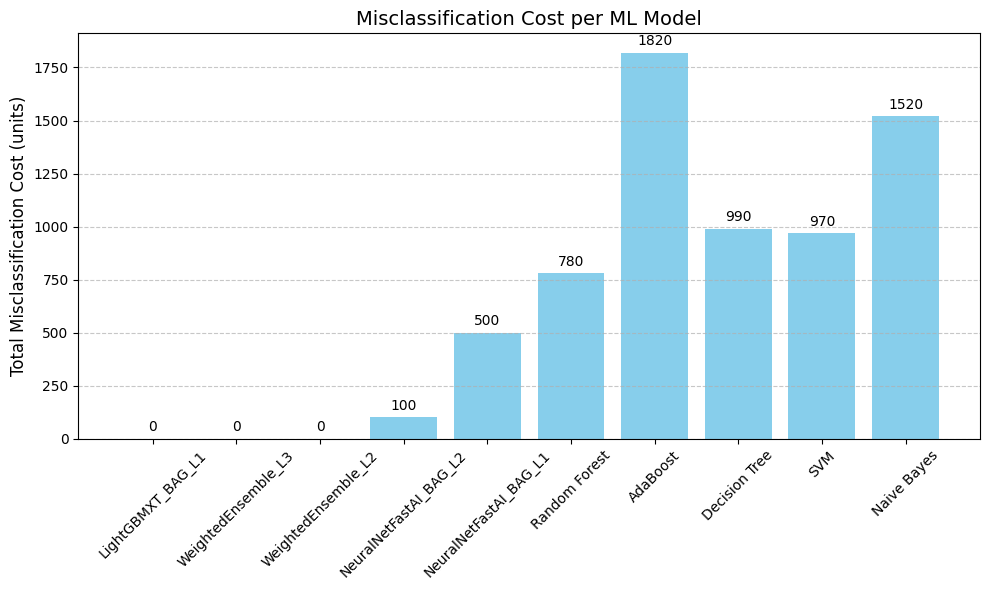

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(model_costs.keys(), model_costs.values(), color='skyblue')
plt.title("Misclassification Cost per ML Model", fontsize=14)
plt.ylabel("Total Misclassification Cost (units)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 20, f'{yval}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


### Training Time for Top 5 AutoGluon Models

In [ ]:
print("\n=== Training Time for Top 5 AutoGluon Models ===")

for model_name in top_5_models:
    fit_time = leaderboard[leaderboard['model'] == model_name]['fit_time'].iloc[0]
    print(f"{model_name}: {fit_time:.2f} seconds")


=== Training Time for Top 5 AutoGluon Models ===
LightGBMXT_BAG_L1: 66.10 seconds
WeightedEnsemble_L3: 66.50 seconds
WeightedEnsemble_L2: 66.33 seconds
NeuralNetFastAI_BAG_L2: 192.62 seconds
NeuralNetFastAI_BAG_L1: 64.75 seconds


## Explainable AI (XAI) for AutoGluon Model

Explainable AI (XAI) is a set of techniques that allow humans to understand the output of machine learning models. As models become more complex (like the ensembles created by AutoGluon), it becomes harder to understand why they make certain predictions. XAI helps by providing insights into feature importance and how individual features contribute to a model's decision-making process.

Here, we will use SHAP (SHapley Additive exPlanations) to interpret the AutoGluon model. SHAP is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using Shapley values from game theory. SHAP values tell us how much each feature contributes to the prediction for a specific instance, compared to the baseline prediction.

In [ ]:
# Now install shap, which should use the newly installed compatible numpy and scipy
!pip install shap



### Preparing Data for SHAP and Calculating SHAP Values

To calculate SHAP values, we need to consider the `predictor` object from AutoGluon and the test data (`X_test_unscaled_df`). Since AutoGluon ensembles can be complex, `shap.KernelExplainer` is a general choice that works for any black-box model. However, `KernelExplainer` can be computationally intensive, especially on larger datasets.

For practical demonstration, we will select a subset of the `X_test_unscaled_df` to compute SHAP values for, to avoid excessively long computation times.

In [ ]:
import shap
import numpy as np

# Select a subset of the test data for SHAP explanation to manage computation time
# Using a smaller sample makes the process faster for demonstration purposes.
# For full analysis, consider using the entire X_test_unscaled_df or a larger sample.

# Ensure X_test_unscaled_df is a DataFrame for proper SHAP handling
if not isinstance(X_test_unscaled_df, pd.DataFrame):
    X_test_unscaled_df = pd.DataFrame(X_test_unscaled_df, columns=X.columns) # assuming X.columns are available from original X

sample_size = min(100, len(X_test_unscaled_df)) # Limit to 10 samples or less if test set is smaller
X_test_sample = X_test_unscaled_df.sample(n=sample_size, random_state=42)

# Define a prediction function for SHAP explainer
# AutoGluon's predict_proba works well for this.
# The predictor.predict_proba method returns probabilities for each class.
# KernelExplainer needs a function that takes a 2D numpy array or DataFrame and returns predictions.

def predict_proba_autogluon(X_input):
    # Ensure the input is a DataFrame with the correct columns
    if not isinstance(X_input, pd.DataFrame):
        X_input_df = pd.DataFrame(X_input, columns=X_test_unscaled_df.columns)
    else:
        X_input_df = X_input
    return predictor.predict_proba(X_input_df).values

# Create a SHAP KernelExplainer
# The explainer needs a background dataset to estimate feature contributions.
# Using a small sample of the training data as the background is common.
# The training data used by AutoGluon was 'train_data', which is the 'df' before splitting.

# Ensure train_data is available and has the correct columns
if 'train_data' in locals() and isinstance(train_data, pd.DataFrame):
    background_data = train_data.drop(columns=[label]).sample(min(10, len(train_data)), random_state=42)
else:
    # Fallback if train_data is not directly available or not a DataFrame
    # Use a small sample from the original X features (before scaling/splitting)
    background_data = X.sample(min(10, len(X)), random_state=42) # X is unscaled features

explainer = shap.KernelExplainer(predict_proba_autogluon, background_data)

print(f"Calculating SHAP values for {len(X_test_sample)} samples. This might take a moment...")

# Calculate SHAP values for the test sample
# The output will be a list of SHAP values for each class
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculation complete.")

Calculating SHAP values for 100 samples. This might take a moment...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculation complete.


### Visualizing SHAP Results

Once SHAP values are calculated, we can visualize them to understand the model's behavior.

1.  **Summary Plot:** Shows the overall feature importance and the impact of each feature across the dataset.
2.  **Force Plot:** Explains a single prediction, showing how each feature pushes the prediction from the base value (average prediction) to the final output.

Displaying SHAP summary plot for class: Other_Faults


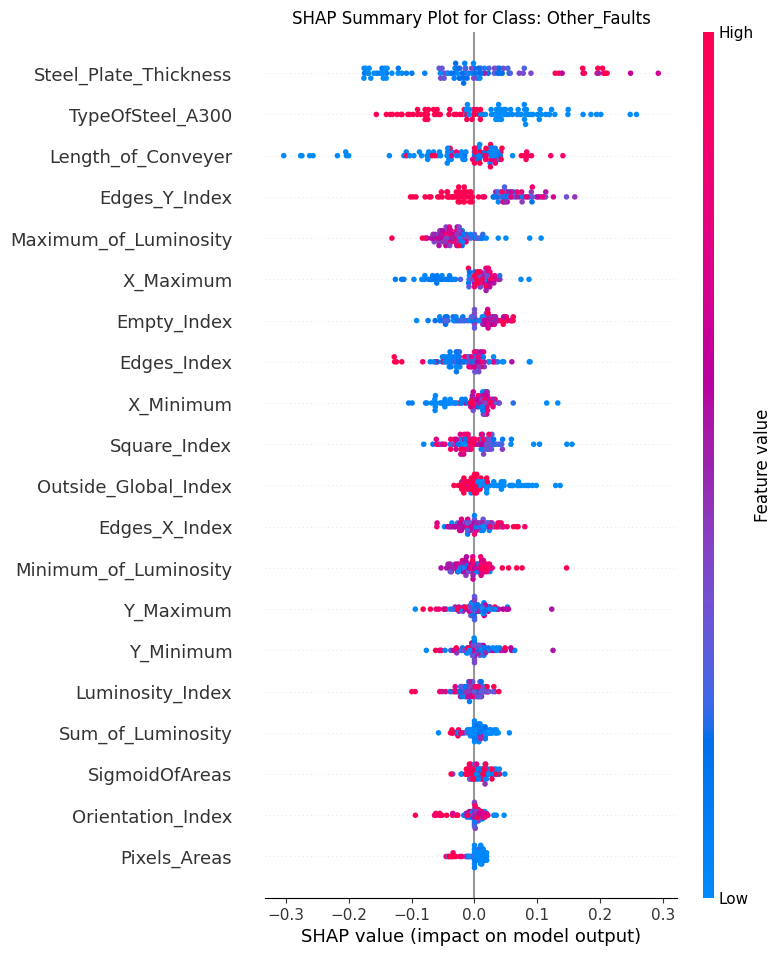


Displaying SHAP force plot for instance 15 (True label: Other_Faults, Predicted label: Other_Faults)


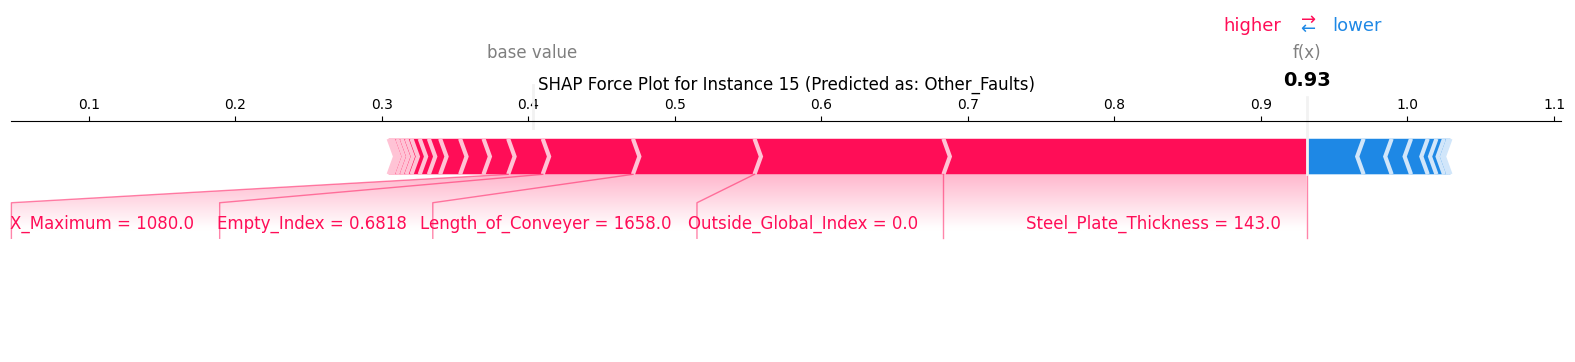

In [ ]:
# Map class indices to actual labels for better interpretability
class_names = predictor.class_labels

# SHAP Summary Plot (Global Feature Importance)
# For multi-class, shap_values is a list of arrays, one for each class.
# We can plot for a specific class or use the average absolute SHAP values.

# Let's start with a summary plot for one of the classes, e.g., 'Other_Faults'
# Find the index of 'Other_Faults' in the class_names list
try:
    other_faults_idx = class_names.index('Other_Faults')
    print(f"Displaying SHAP summary plot for class: {class_names[other_faults_idx]}")
    shap.summary_plot(shap_values[other_faults_idx], X_test_sample, feature_names=X_test_sample.columns, show=False)
    plt.title(f"SHAP Summary Plot for Class: {class_names[other_faults_idx]}")
    plt.show()
except ValueError:
    print("'Other_Faults' not found in class labels. Plotting for the first class instead.")
    shap.summary_plot(shap_values[0], X_test_sample, feature_names=X_test_sample.columns, show=False)
    plt.title(f"SHAP Summary Plot for Class: {class_names[0]}")
    plt.show()


# SHAP Force Plot (Individual Prediction Explanation)
# You can choose any instance from your test sample. Let's pick the first one.
instance_idx = 15
# Corrected: Use .loc with the actual index from X_test_sample to get the true label
true_label_for_instance = y_test.loc[X_test_sample.index[instance_idx]]
# Corrected: Use .iloc[0] to access the first element of the predicted Series by position
predicted_label_for_instance = predictor.predict(X_test_sample.iloc[[instance_idx]]).iloc[0]

print(f"\nDisplaying SHAP force plot for instance {instance_idx} (True label: {true_label_for_instance}, Predicted label: {predicted_label_for_instance})")

# For multiclass, force_plot requires the explainer's expected value and the shap_values for that specific instance.
# It's usually plotted for one specific class's prediction contribution.
# Let's plot for the predicted class of this instance
try:
    predicted_class_idx = class_names.index(predicted_label_for_instance)
    shap.force_plot(explainer.expected_value[predicted_class_idx],
                    shap_values[predicted_class_idx][instance_idx],
                    X_test_sample.iloc[instance_idx],
                    matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot for Instance {instance_idx} (Predicted as: {predicted_label_for_instance})")
    plt.show()
except Exception as e:
    print(f"Could not generate force plot for instance {instance_idx}. Error: {e}")
    print("Ensure that matplotlib is set up correctly for SHAP force plots or try a different instance.")